In [1]:
import pandas as pd
import sqlite3
import os
from pathlib import Path
import numpy as np
import seaborn as sns
import peewee as pw
import matplotlib.pyplot as plt
import sklearn as skl
import pymc as pm

#swithc working directory to 
os.chdir(r'c:\Repositories\asphalt-db')
from main.data_classifications import *
from main.data_processing import *
from src.db_builder.models import *
from main.query_database import *


sns.set_style('whitegrid')
working_dir = Path(r'c:\Repositories\asphalt-db\results')
results_dir = Path(r'c:\Users\klerk_wj\OneDrive - Stichting Deltares\00_Projecten\09_Kvk Asfalt\results')

In [2]:
#load the data
dikes_and_projects = query_dikes_and_projects(sqlite3.connect(working_dir.parent.joinpath('data','database_all_v5.sqlite')))
df_final = load_and_merge_data(working_dir.parent.joinpath('data','database_all_v5.sqlite'))
data_per_dike_project = get_section_based_statistics(df_final, dikes_and_projects)
df_final, data_per_dike_project = classifications_wrapper(df_final, data_per_dike_project)

<Axes: xlabel='age_at_investigation', ylabel='sig_b'>

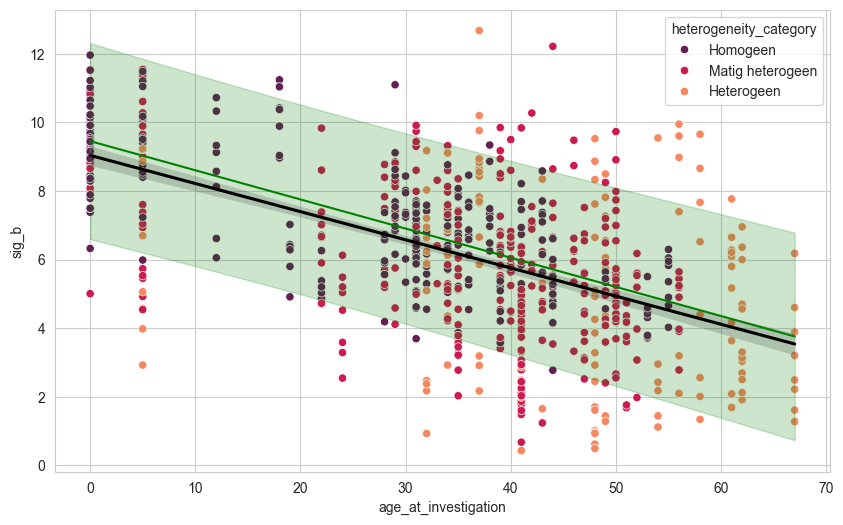

In [3]:
#load the linear regression results
import json
with open('C:\\Repositories\\asphalt-db\\results\\heterogeneity_regression\\log_y_False\\lr_results_M1.json') as f:
    lr_results = json.load(f)
    intercept = lr_results['Homogeen']['beta'][0]
    slope = lr_results['Homogeen']['beta'][1]
    std_intercept, std_slope = lr_results['Homogeen']['beta_ste']
    covariance_matrix = np.array(lr_results['Homogeen']['beta_cov'])
    standard_error = lr_results['Homogeen']['se']

x_grid = np.linspace(0, max(df_final['age_at_investigation']), 100)
#combined standard error for slope & intercept at each x value
standard_error_regression = np.sqrt(std_intercept**2 + (x_grid * std_slope)**2 + 2 * x_grid * covariance_matrix[0,1])
#plot the data with regression line and preiction interval
hue_order = ['Homogeen', 'Matig heterogeen', 'Heterogeen']
prediction_y = intercept + slope * x_grid

fig, ax = plt.subplots(figsize=(10,6))
sns.scatterplot(data=df_final, x= 'age_at_investigation', y = 'sig_b', hue='heterogeneity_category', hue_order=hue_order, palette='rocket',ax=ax)
ax.plot(x_grid, prediction_y, color='green', label='Regressie homogeen')
ax.fill_between(x_grid, prediction_y - 1.96*(standard_error+standard_error_regression), prediction_y + 1.96*(standard_error+standard_error_regression), color='green', alpha=0.2)

sns.regplot(data=df_final, x='age_at_investigation', y='sig_b', scatter=False, color='black',ax=ax, label= 'Regressie alle vakken')

(-1.0, 51.0)

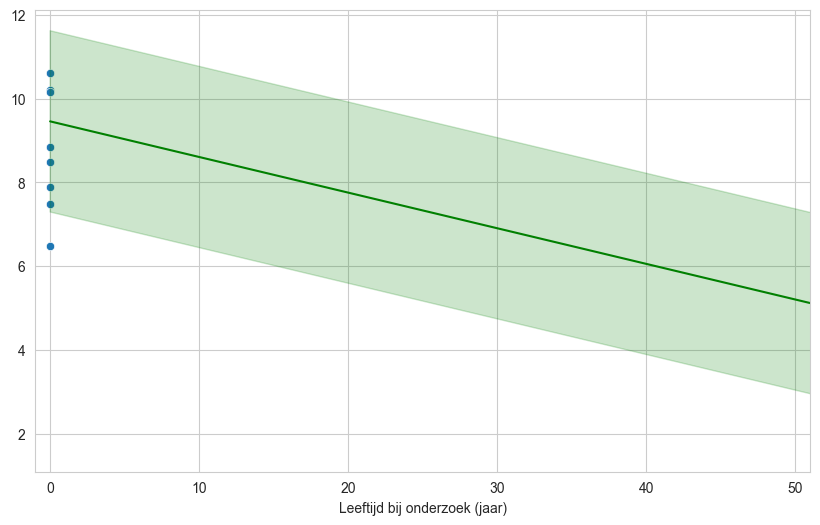

In [45]:
# at t = 0 we get 8 samples from a normal distribution with mean 10 and std 1.7
import scipy.stats as stats
n = 8
mean = 8
std = 1.0
samples = np.random.normal(loc=mean, scale=std, size=n)
#drop nan values for sig_b from df_final
df_final = df_final.loc[(df_final["sig_b"]>0) & (~df_final["sig_b"].isna())]

#plot regression and samples
fig, ax = plt.subplots(figsize=(10,6))
sns.scatterplot(x=[0]*n, y=samples, ax=ax)
ax.plot(x_grid, prediction_y, color='green', label='Regressie homogeen')
ax.fill_between(x_grid, prediction_y - 1.645*standard_error, prediction_y + 1.645*standard_error, color='green', alpha=0.2)
ax.set_xlabel('Leeftijd bij onderzoek (jaar)')
ax.set_xlim(-1,51)



Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, slope, sigma]


c:\Users\klerk_wj\.conda\envs\statistical_modelling\Lib\site-packages\rich\live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 38 seconds.


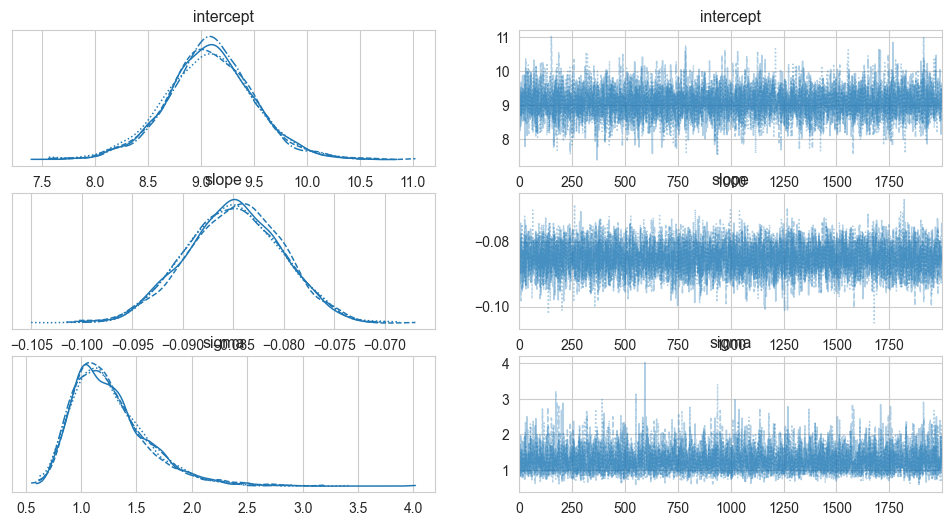

In [46]:
sig_b_observations_1 = np.random.normal(loc=mean, scale=std, size=n)
ages_observations_1 = np.zeros(n)


with pm.Model() as model:
    ages_at_observation = pm.Data('ages_at_observation', ages_observations_1)
    observations = pm.Data('observations', sig_b_observations_1)

    #build prior model of regression
    # intercept_prior = pm.Normal('intercept', mu=intercept, sigma=std_intercept)
    intercept_prior = pm.Normal('intercept', mu=intercept, sigma=standard_error)
    slope_prior = pm.Normal('slope', mu=slope, sigma=std_slope)
    sigma_prior = pm.HalfNormal('sigma', sigma=standard_error)

    # Expected value of outcome
    mu = intercept_prior + slope_prior * ages_at_observation

    # Sampling  of observations from observations set
    Y_obs = pm.Normal('Y_obs', mu=mu, sigma=sigma_prior, observed=observations)


    # Inference
    trace1 = pm.sample(2000, tune=1000, return_inferencedata=True)
    pm.plot_trace(trace1)

Text(0, 0.5, 'Buigtreksterkte (MPa)')

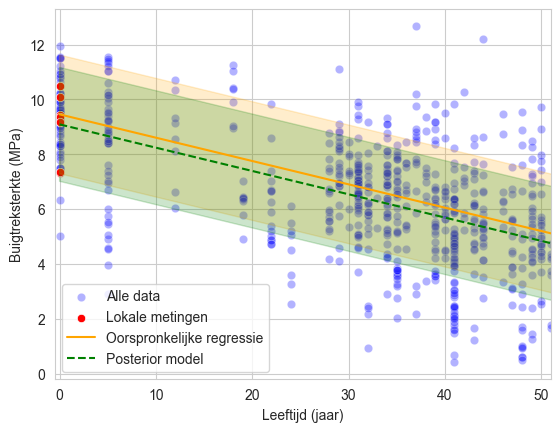

In [47]:
#plot the posterior model and compare with original
sns.scatterplot(x=df_final['age_at_investigation'], y=df_final['sig_b'], color='blue', alpha=0.3, label='Alle data')
sns.scatterplot(x=ages_observations_1, y=sig_b_observations_1, color='red', label= 'Lokale metingen')
x_grid = np.linspace(0, max(df_final['age_at_investigation']), 100)
posterior_intercept_1 = trace1.posterior['intercept'].mean().values
posterior_slope_1 = trace1.posterior['slope'].mean().values

#also add original regression for reference
plt.plot(x_grid, intercept + slope * x_grid, color='orange', label='Oorspronkelijke regressie')
plt.fill_between(x_grid, 
                 intercept + slope * x_grid - 1.645*standard_error, 
                 intercept + slope * x_grid + 1.645*standard_error, 
                 color='orange', alpha=0.2)

#add posterior
plt.plot(x_grid, posterior_intercept_1 + posterior_slope_1 * x_grid, color='green', label='Posterior model',linestyle='--')
#add prediction interval of posterior
plt.fill_between(x_grid, 
                 posterior_intercept_1 + posterior_slope_1 * x_grid - 1.645*trace1.posterior['sigma'].mean().values, 
                 posterior_intercept_1 + posterior_slope_1 * x_grid + 1.645*trace1.posterior['sigma'].mean().values, 
                 color='green', alpha=0.2)

# plt.axhline(y=3.0, color='red', linestyle=':', label='Kritieke waarde $\sigma_b$')

plt.legend()
plt.xlim(-0.5,51)
plt.xlabel('Leeftijd (jaar)')
plt.ylabel('Buigtreksterkte (MPa)')

Better formulation for regression would be:
normal intercpet
halfnormal slope 
sigma as halfnormal
and for mu = intercept_prior - slope_prior * ages at observation

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, slope, sigma]


c:\Users\klerk_wj\.conda\envs\statistical_modelling\Lib\site-packages\rich\live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 33 seconds.
There were 7 divergences after tuning. Increase `target_accept` or reparameterize.


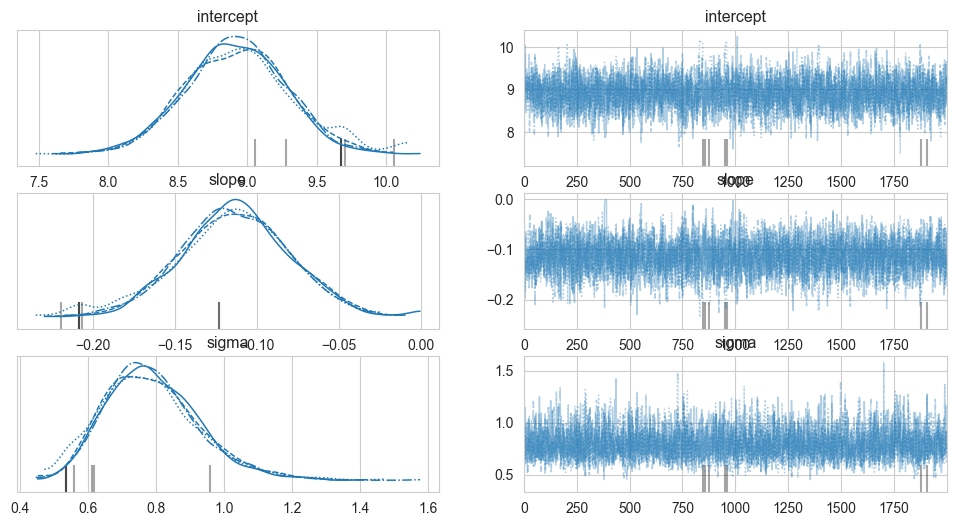

In [48]:

#now we add observations at t=15
sig_b_observations_2 = np.random.normal(loc=7.3, scale=1.2, size=n)
ages_observations_2 = np.full(n, 12)


with pm.Model() as model:
    ages_at_observation = pm.Data('ages_at_observation', ages_observations_2)
    observations = pm.Data('observations', sig_b_observations_2)

    #build use previous posterior as prior
    intercept_prior = pm.Normal('intercept', mu=posterior_intercept_1, sigma=trace1.posterior['intercept'].std().values)
    slope_prior = pm.TruncatedNormal('slope', mu=posterior_slope_1, sigma=0.05, upper=0)
    sigma_prior = pm.HalfNormal('sigma', sigma=trace1.posterior['sigma'].std().values)

    # Expected value of outcome
    mu = intercept_prior + slope_prior * ages_at_observation

    # Sampling  of observations from observations set
    Y_obs = pm.Normal('Y_obs', mu=mu, sigma=sigma_prior, observed=observations)


    # Inference
    trace2 = pm.sample(2000, tune=1000, return_inferencedata=True)
    pm.plot_trace(trace2)

(-0.5, 51.0)

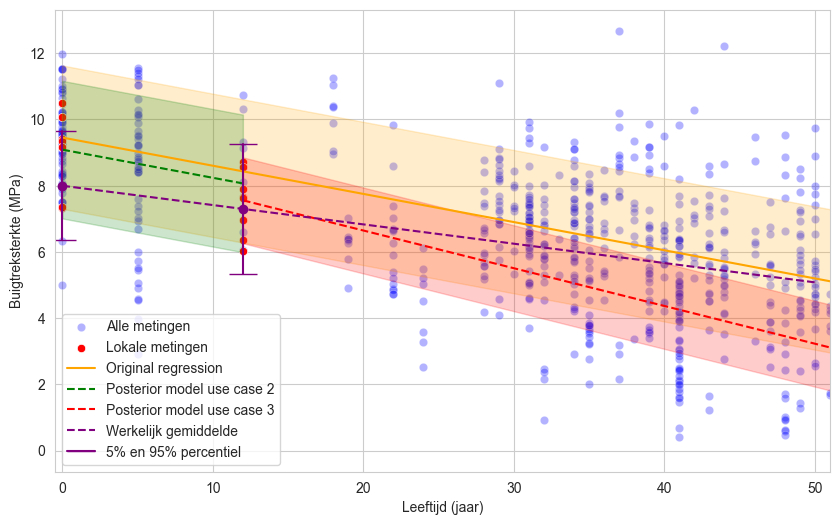

In [49]:
#plot the posterior model and compare with original
fig, ax = plt.subplots(figsize=(10,6))
sns.scatterplot(x=df_final['age_at_investigation'], y=df_final['sig_b'], color='blue', alpha=0.3, label='Alle metingen')
sns.scatterplot(x=np.concatenate([ages_observations_1, ages_observations_2]), y=np.concatenate([sig_b_observations_1, sig_b_observations_2]), color='red', label= 'Lokale metingen')
x_grid1 = np.linspace(0, 12, 100)
x_grid2 = np.linspace(12, max(df_final['age_at_investigation']), 100)
x_grid_total = np.concatenate([x_grid1, x_grid2])
posterior_intercept_2 = trace2.posterior['intercept'].mean().values
posterior_slope_2 = trace2.posterior['slope'].mean().values

#first add original regression for reference
ax.plot(x_grid_total, intercept + slope * x_grid_total, color='orange', label='Original regression')
ax.fill_between(x_grid_total, 
                 intercept + slope * x_grid_total - 1.645*standard_error, 
                 intercept + slope * x_grid_total + 1.645*standard_error, 
                 color='orange', alpha=0.2)

#add posterior for part up to 20 based on first run
ax.plot(x_grid1, posterior_intercept_1 + posterior_slope_1 * x_grid1, color='green', label='Posterior model use case 2',linestyle='--')
#add prediction interval of posterior
ax.fill_between(x_grid1, 
                 posterior_intercept_1 + posterior_slope_1 * x_grid1 - 1.645*trace1.posterior['sigma'].mean().values, 
                 posterior_intercept_1 + posterior_slope_1 * x_grid1 + 1.645*trace1.posterior['sigma'].mean().values, 
                 color='green', alpha=0.2)

#add posterior for part after 20 based on second run
ax.plot(x_grid2, posterior_intercept_2 + posterior_slope_2 * x_grid2, color='red', label='Posterior model use case 3',linestyle='--')
#add prediction interval of posterior
ax.fill_between(x_grid2, 
                 posterior_intercept_2 + posterior_slope_2 * x_grid2 - 1.645*trace2.posterior['sigma'].mean().values, 
                 posterior_intercept_2 + posterior_slope_2 * x_grid2 + 1.645*trace2.posterior['sigma'].mean().values, 
                 color='red', alpha=0.2)
#werkelijk gemiddelde
#t=0 sig_b=8
#t=20 sig_b=7.5
ax.plot([0,12], [8,7.3], color='purple', marker='o', linestyle='')

ax.plot([0,50], [8,true_mean_t50], color='purple', linestyle='--',label = 'Werkelijk gemiddelde')
#5% and 95% percentiles for t=0
ax.plot([0,0], [stats.norm.ppf(0.05, loc=8, scale=1.0), stats.norm.ppf(0.95, loc=8, scale=1.0)], color='purple', linestyle='-', marker = '_', markersize=20)
#same for t=12
ax.plot([12,12], [stats.norm.ppf(0.05, loc=7.3, scale=1.2), stats.norm.ppf(0.95, loc=7.3, scale=1.2)], color='purple', linestyle='-', marker = '_', markersize=20, label='5% en 95% percentiel')
#plot line for true mean until t=50
#comput sig_b at t=50
true_mean_t50 = 8 - ((0.7/12) * 50)

ax.legend()
ax.set_xlabel('Leeftijd (jaar)')
ax.set_ylabel('Buigtreksterkte (MPa)')
ax.set_xlim(-0.5,51)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, slope, sigma]


c:\Users\klerk_wj\.conda\envs\statistical_modelling\Lib\site-packages\rich\live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 26 seconds.


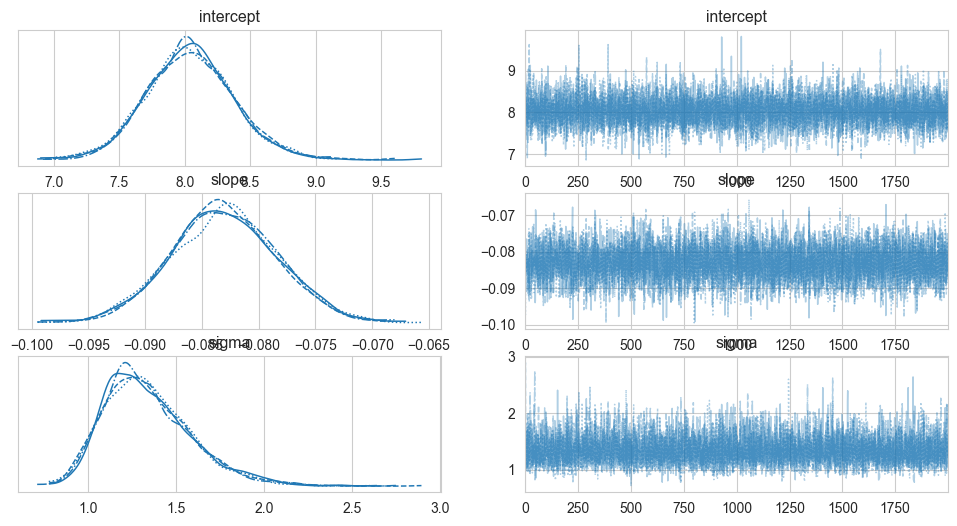

In [9]:
#now we do the same, but update the prior immediately with all the observations
sig_b_observations_3 = np.concatenate([sig_b_observations_1, sig_b_observations_2])
ages_observations_3 = np.concatenate([ages_observations_1, ages_observations_2])

with pm.Model() as model:
    ages_at_observation = pm.Data('ages_at_observation', ages_observations_3)
    observations = pm.Data('observations', sig_b_observations_3)

    #build use previous posterior as prior
    intercept_prior = pm.Normal('intercept', mu=intercept, sigma=standard_error)
    slope_prior = pm.Normal('slope', mu=slope, sigma=std_slope)
    sigma_prior = pm.HalfNormal('sigma', sigma=standard_error)

    # Expected value of outcome
    mu = intercept_prior + slope_prior * ages_at_observation

    # Sampling  of observations from observations set
    Y_obs = pm.Normal('Y_obs', mu=mu, sigma=sigma_prior, observed=observations)


    # Inference
    trace3 = pm.sample(2000, tune=1000, return_inferencedata=True)
    pm.plot_trace(trace3)

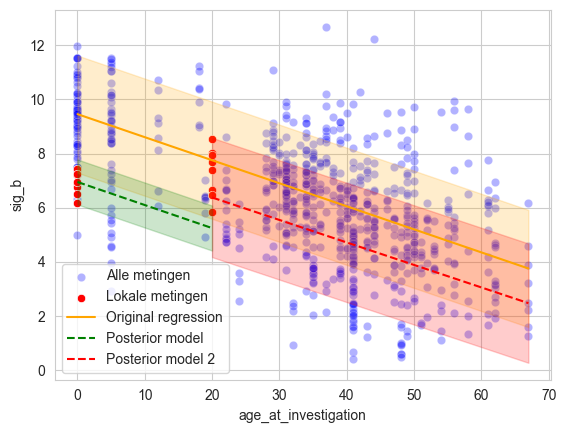

In [10]:
#plot the posterior model and compare with original
sns.scatterplot(x=df_final['age_at_investigation'], y=df_final['sig_b'], color='blue', alpha=0.3, label='Alle metingen')
sns.scatterplot(x=np.concatenate([ages_observations_1, ages_observations_2]), y=np.concatenate([sig_b_observations_1, sig_b_observations_2]), color='red', label= 'Lokale metingen')
x_grid1 = np.linspace(0, 20, 100)
x_grid2 = np.linspace(20, max(df_final['age_at_investigation']), 100)
x_grid_total = np.concatenate([x_grid1, x_grid2])
posterior_intercept_3 = trace3.posterior['intercept'].mean().values
posterior_slope_3 = trace3.posterior['slope'].mean().values

#first add original regression for reference
plt.plot(x_grid_total, intercept + slope * x_grid_total, color='orange', label='Original regression')
plt.fill_between(x_grid_total, 
                 intercept + slope * x_grid_total - 1.645*standard_error, 
                 intercept + slope * x_grid_total + 1.645*standard_error, 
                 color='orange', alpha=0.2)

#add posterior for part up to 20 based on first run
plt.plot(x_grid1, posterior_intercept_1 + posterior_slope_1 * x_grid1, color='green', label='Posterior model',linestyle='--')
#add prediction interval of posterior
plt.fill_between(x_grid1, 
                 posterior_intercept_1 + posterior_slope_1 * x_grid1 - 1.645*trace1.posterior['sigma'].mean().values, 
                 posterior_intercept_1 + posterior_slope_1 * x_grid1 + 1.645*trace1.posterior['sigma'].mean().values, 
                 color='green', alpha=0.2)

#add posterior for part after 20 based on new run with all data
plt.plot(x_grid2, posterior_intercept_3 + posterior_slope_3 * x_grid2, color='red', label='Posterior model 2',linestyle='--')
#add prediction interval of posterior
plt.fill_between(x_grid2, 
                 posterior_intercept_3 + posterior_slope_3 * x_grid2 - 1.645*trace3.posterior['sigma'].mean().values, 
                 posterior_intercept_3 + posterior_slope_3 * x_grid2 + 1.645*trace3.posterior['sigma'].mean().values, 
                 color='red', alpha=0.2)

plt.legend()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, slope, sigma]


c:\Users\klerk_wj\.conda\envs\statistical_modelling\Lib\site-packages\rich\live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 28 seconds.


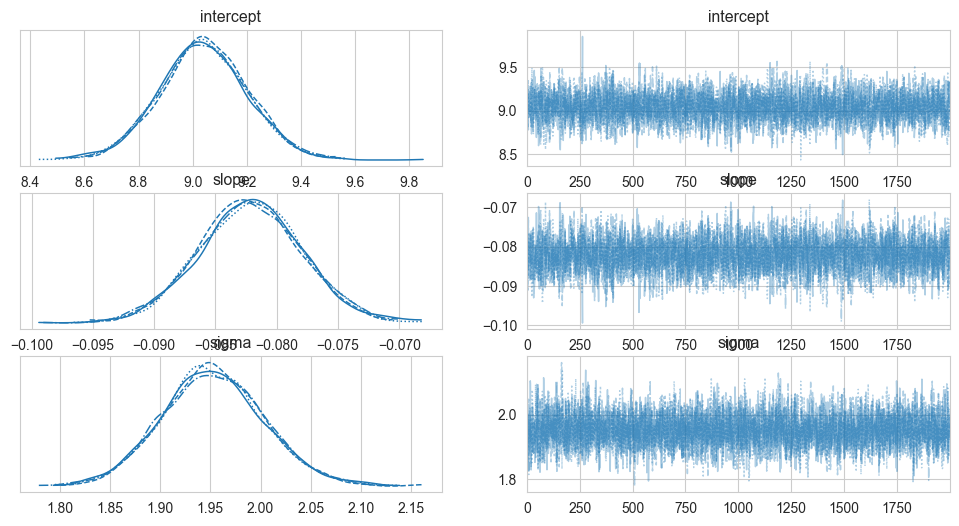

In [11]:
#make a prior Bayesian regression model based on df_final

with pm.Model() as model:
    ages_at_observation = pm.Data('ages_at_observation', df_final['age_at_investigation'].values)
    observations = pm.Data('observations', df_final['sig_b'].values)

    #use uninformative priors
    intercept_prior = pm.Normal('intercept', mu=5, sigma=10)
    slope_prior = pm.Normal('slope', mu=0, sigma=1)
    sigma_prior = pm.HalfNormal('sigma', sigma=10)

    # Expected value of outcome
    mu = intercept_prior + slope_prior * ages_at_observation

    # Sampling  of observations from observations set
    Y_obs = pm.Normal('Y_obs', mu=mu, sigma=sigma_prior, observed=observations)


    # Inference
    trace4 = pm.sample(2000, tune=1000, return_inferencedata=True)
    pm.plot_trace(trace4)

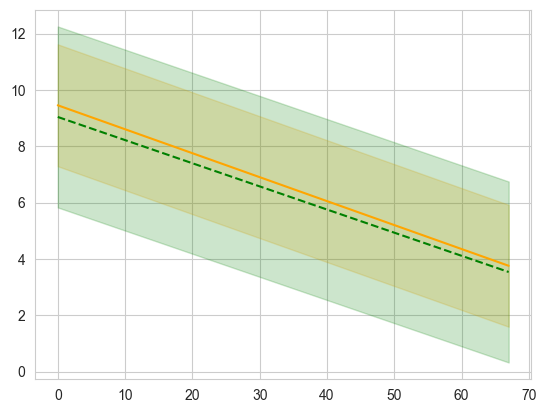

In [12]:
#first add original regression for reference
plt.plot(x_grid_total, intercept + slope * x_grid_total, color='orange', label='Original regression')
plt.fill_between(x_grid_total, 
                 intercept + slope * x_grid_total - 1.645*standard_error, 
                 intercept + slope * x_grid_total + 1.645*standard_error, 
                 color='orange', alpha=0.2)

#then plot the posterior regression
posterior_intercept_4 = trace4.posterior['intercept'].mean().values
posterior_slope_4 = trace4.posterior['slope'].mean().values

plt.plot(x_grid_total, posterior_intercept_4 + posterior_slope_4 * x_grid_total, color='green', label='Posterior model',linestyle='--')
#add prediction interval of posterior
plt.fill_between(x_grid_total, 
                 posterior_intercept_4 + posterior_slope_4 * x_grid_total - 1.645*trace4.posterior['sigma'].mean().values, 
                 posterior_intercept_4 + posterior_slope_4 * x_grid_total + 1.645*trace4.posterior['sigma'].mean().values, 
                 color='green', alpha=0.2)